## 데이터분석 모형 (6단원-1 통계)

### 1.수업을 위한 data  활용을 위해 깃허브 연동하기

In [ ]:
!git clone 'https://'github.com/KangKyungHwa/DSMH_2/''

fatal: destination path 'DSMH_2' already exists and is not an empty directory.


### 2. 원활한 한글 인식을 위해 폰트 설치

In [ ]:
# 1. 나눔고딕 폰트 설치
!sudo apt-get update -qq
!sudo apt-get install -y fonts-nanum-extra -qq

# 2. 시스템 폰트 캐시 업데이트
!sudo fc-cache -fv

# 3. Matplotlib 폰트 캐시 삭제
!rm -rf ~/.cache/matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 33 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

### 3. 나눔고딕 설치

In [ ]:
from matplotlib import pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['axes.unicode_minus'] = False

### 4.현재 설치된 폰트 확인

In [ ]:
import matplotlib.pyplot as plt

print("현재 Matplotlib 폰트 설정:", plt.rcParams['font.family']) #현재 설치된 폰트 확인


현재 Matplotlib 폰트 설정: ['NanumGothic']


### 5. 통계 라이브러리 불러오기 및  실습(1)

#### 6-1 예제)  A 기업에서 생산하는 건전지의 평균수명을 조사하기 위해 생산된 10개의 건전지를 조사한 수명 시간에 대한 모집단 평균의 95% 신뢰구간 계산하기

In [ ]:
import numpy as np
import scipy.stats as st      # scipy 라이브러리의 통계서브모듈 불러오기
from scipy.stats import t     # stats 서브모듈에서 st.sem(), t.ppf(), st.t.interval() 함수 사용

a = [260,265,250,270,272,258,262,268,270,252]

print('평균=', np.mean(a),'\n')
print('표준편차=', np.std(a),'\n')         # 표준편차: 데이터셋 자체의 산포도를 측정
print('표준오차=', st.sem(a),'\n')         # 표본 통계량의 정확도를 측정
print('t값=', t.ppf(0.975,10-1),'\n')
print('신뢰구간 t.interval = ','\n')
print(st.t.interval(0.95, len(a)-1, loc=np.mean(a), scale=st.sem(a)),'\n')

평균= 262.7 

표준편차= 7.294518489934754 

표준오차= 2.4315061633115844 

t값= 2.2621571628540993 

신뢰구간 t.interval =  

(np.float64(257.1995509161408), np.float64(268.20044908385916)) 



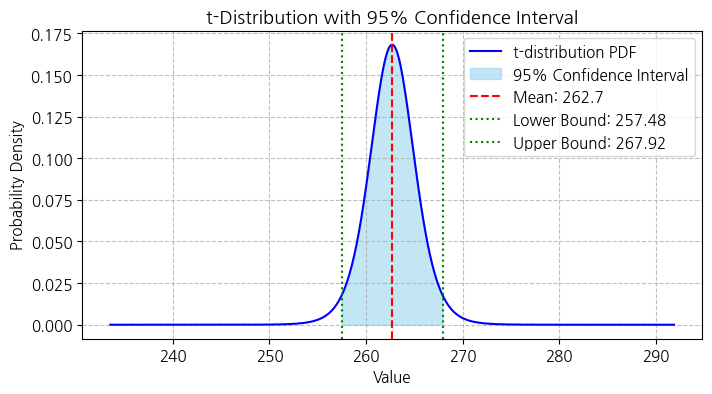

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# 위의 예제 시가화
n = len(a)
mean = np.mean(a)
std = np.std(a)
confidence_level = 0.95

# 평균에 대한 표준 오차
sem = std / np.sqrt(n)

# 신뢰구간 계산
lower_bound, upper_bound = st.t.interval(confidence_level, df=n-1, loc=mean, scale=sem)

# 플롯을 위한 x 값 생성 (분포의 더 넓은 범위를 포함)
x = np.linspace(mean - 4 * sem * np.sqrt(n), mean + 4 * sem * np.sqrt(n), 500)

# Calculate the probability density function (PDF) for the t-distribution
df = n - 1 # degrees of freedom (자유도)
pdf = st.t.pdf(x, df, loc=mean, scale=sem)  # loc : 표본평균

# plot 그래프 만들기
plt.figure(figsize=(8, 4))
plt.plot(x, pdf, color='blue', label='t-distribution PDF')

# Shade the confidence interval area
x_interval = np.linspace(lower_bound, upper_bound, 100)
y_interval = st.t.pdf(x_interval, df, loc=mean, scale=sem)
plt.fill_between(x_interval, y_interval, color='skyblue', alpha=0.5, label='95% Confidence Interval')

# Add vertical lines for the mean and interval bounds
plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean}')
plt.axvline(lower_bound, color='green', linestyle=':', label=f'Lower Bound: {lower_bound:.2f}')
plt.axvline(upper_bound, color='green', linestyle=':', label=f'Upper Bound: {upper_bound:.2f}')

# Add plot details
plt.title('t-Distribution with 95% Confidence Interval')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.8)
plt.show()

### 6. 통계 실습(2)

#### 6-1 예제2) 사당에서 출발하는 통학버스의 학교도착 소요시간을 25번 조사한 결과 평균이 35분, 표준편차는 5분으로 조사되었다.  소요시간 평균에 대한 95% 신뢰구간을 계산하기